---
title: Multiple Travel Matrices
toc: true
execute: 
  enabled: true
image: image.png
---

Sometimes we want to weigh up more than one travel mode at once -- for example, how a set of sites performs for car travel *and* for public transport, in a single ranked list of candidate solutions.

[The 'comparing solutions' example](../comparing_solutions/index.ipynb) shows how to do this by solving the same problem twice (once per mode, via `problem.copy()`) and then reconciling the two independently-ranked `SiteSolutionSet`s with `SolutionComparator`. That approach is the right one when the two modes genuinely need separate optimisations -- but the two solution sets are ranked over different orderings, and `SolutionComparator.find_balanced_solution()` can only reconcile them heuristically, by scoring how much their selected sites overlap.

This example instead registers public transport as a **secondary travel matrix** on a single problem. The primary matrix (car) still drives which combinations of sites get searched and pruned, but every solution `solve()` returns also carries public transport metrics alongside the car ones -- so we get one ranked list, with both modes' numbers side by side, ready to trade off directly with a Pareto front.

In [1]:
from lokigi.site import SiteProblem
from lokigi.multiobjective import Metric

As with the comparing solutions example, we'll use the Devon minor injury unit sites, but this time we only need a single `SiteProblem` -- we don't need to `.copy()` it per mode.

In [2]:
problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_mius.geojson",
    candidate_id_col="Facility_Name"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

Now we add our **primary** travel matrix -- car -- exactly as usual, via `add_travel_matrix()`. This is the matrix that `solve()` will optimise against.

In [3]:
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix.csv",
    source_col="from_id",
    unit="minutes",
    )

Then we register public transport as a **secondary** travel matrix via `add_secondary_travel_matrix()`. It takes the same `travel_matrix_df`/`source_col`/unit arguments as `add_travel_matrix()`, plus a required `label` (used to name every metric column this matrix contributes) and an optional per-matrix `threshold_for_coverage` -- public transport journeys are typically slower, so we'll use a more generous 60-minute threshold here, independent of whatever threshold we pass to `solve()` for the primary (car) matrix.

You can register as many secondary matrices as you like this way -- each one just needs its own unique `label`.

In [4]:
problem.add_secondary_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix_public_transport_extended.csv",
    source_col="from_id",
    label="public_transport",
    unit="minutes",
    threshold_for_coverage=60,
    )

Now we solve **once**. The `threshold_for_coverage=20` here only applies to the primary (car) matrix, since public transport already has its own threshold of 60 minutes set at registration time above.

In [5]:
solution = problem.solve(p=4, threshold_for_coverage=20)

C:\lokigi\lokigi\site.py:1160: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/1365 [00:00<?, ?it/s]

Let's look at the column names now available. Alongside the usual car-based metrics (`weighted_average`, `max`, `proportion_within_coverage_threshold`, ...), every one of those core metrics now also has a `public_transport`-suffixed sibling.

In [6]:
solution.show_solutions_colnames()

Index(['solution_rank', 'site_names', 'site_indices', 'unselected_site_names',
       'coverage_threshold', 'weighted_average', 'unweighted_average',
       '90th_percentile', 'max', 'weighted_average_for_ranking',
       'unweighted_average_for_ranking', 'max_for_ranking', 'total_cost',
       'proportion_within_coverage_threshold',
       'proportion_regions_within_coverage_threshold',
       'demand_within_coverage_threshold', 'regions_within_coverage_threshold',
       'regions_unreachable', 'demand_unreachable',
       'proportion_demand_unreachable', 'weighted_by_equity_group',
       'unweighted_by_equity_group', 'coverage_by_equity_group',
       'coverage_regions_by_equity_group', 'max_cost_by_equity_group',
       'regions_unreachable_by_equity_group',
       'demand_unreachable_by_equity_group', 'gap_absolute_weighted',
       'gap_relative_weighted', 'avg_lower_third_bins',
       'avg_middle_third_bins', 'avg_upper_third_bins', 'inter_tertile_ratio',
       'gap_absolute_d

In [7]:
solution.show_solutions().head()

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,weighted_average_for_ranking,...,regions_within_coverage_threshold__public_transport,regions_unreachable__public_transport,demand_unreachable__public_transport,proportion_demand_unreachable__public_transport,gap_absolute_weighted__public_transport,gap_relative_weighted__public_transport,avg_lower_third_bins__public_transport,avg_middle_third_bins__public_transport,avg_upper_third_bins__public_transport,inter_tertile_ratio__public_transport
0,1,"[North Devon District Hospital, Totnes Communi...","[0, 6, 7, 11]","[Honiton Hospital, Tiverton & District Hospita...",20,20.23,20.23,33.0,64.0,20.23,...,292,0,0.0,0.0,None,None,None,None,None,None
1,2,"[North Devon District Hospital, Newton Abbot C...","[0, 5, 7, 11]","[Honiton Hospital, Tiverton & District Hospita...",20,20.68,20.68,34.4,64.0,20.68,...,289,0,0.0,0.0,None,None,None,None,None,None
2,3,"[Totnes Community Hospital, NHS Walk in Centre...","[6, 7, 11, 13]","[North Devon District Hospital, Honiton Hospit...",20,20.91,20.91,34.0,68.0,20.91,...,270,0,0.0,0.0,None,None,None,None,None,None
3,4,"[North Devon District Hospital, Totnes Communi...","[0, 6, 7, 10]","[Honiton Hospital, Tiverton & District Hospita...",20,21.10,21.10,34.0,64.0,21.10,...,285,0,0.0,0.0,None,None,None,None,None,None
4,5,"[Totnes Community Hospital, NHS Walk in Centre...","[6, 7, 11, 12]","[North Devon District Hospital, Honiton Hospit...",20,21.16,21.16,37.4,70.0,21.16,...,279,0,0.0,0.0,None,None,None,None,None,None


## Exploring the trade-off with a Pareto front

Because both modes' metrics live on the same ranked list, we can trade them off directly with the same Pareto tooling used for e.g. cost vs equity in [the Pareto fronts example](../multiobjective_optimisation_pareto/index.ipynb) -- there's nothing secondary-matrix-specific about `compute_pareto_front()` or `plot_simple_pareto_front_pairs()`, they just consume whichever `solution_df` columns you point them at.

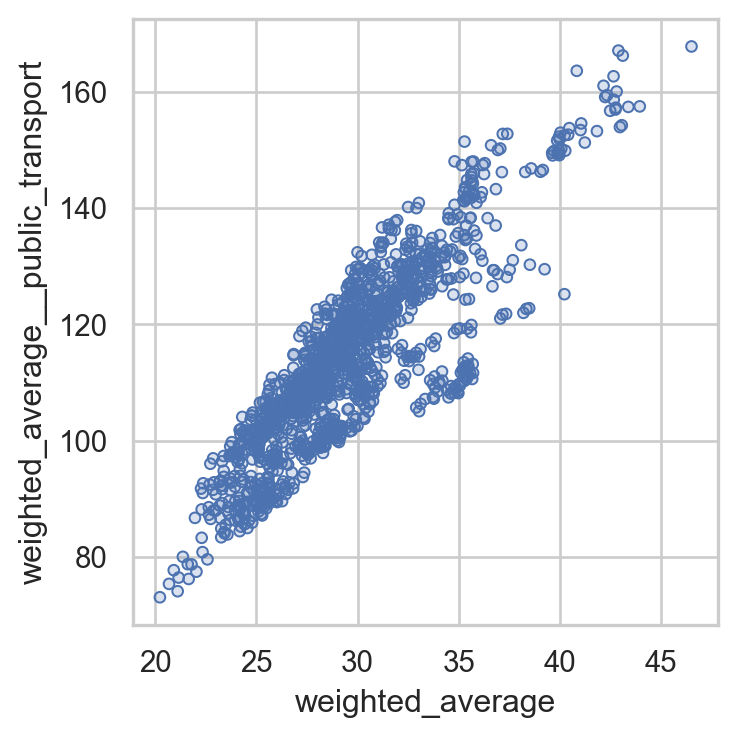

In [8]:
solution.plot_simple_pareto_front_pairs(
    x_axis="weighted_average",
    y_axis="weighted_average__public_transport",
    )

We can bring in more metrics at once with `Metric` -- here, car weighted average travel time, public transport weighted average travel time, and public transport coverage.

In [9]:
metrics = [
    Metric(column="weighted_average", direction="lower_better",
                 label="car weighted average travel time", unit="minutes"),
    Metric(column="weighted_average__public_transport", direction="lower_better",
                 label="public transport weighted average travel time", unit="minutes"),
    Metric(column="proportion_within_coverage_threshold__public_transport", direction="higher_better",
                 label="public transport coverage"),
    Metric(column="max__public_transport", direction="lower_better",
                 label="public transport max travel time", unit="minutes"),
    ]

solution.compute_pareto_front(metrics=metrics)

solution.pareto_summary()

,solution_rank,weighted_average,weighted_average__public_transport,proportion_within_coverage_threshold__public_transport,max__public_transport
0,1,20.227723,73.074965,0.413013,294.0
1,12,22.260255,91.759547,0.294201,288.0
2,16,22.367751,92.676096,0.289958,281.0
3,18,22.643564,88.555870,0.298444,266.0
4,19,22.649222,87.267327,0.302687,266.0
5,34,23.261669,84.906648,0.381895,262.0
6,43,23.403112,84.260255,0.373409,262.0
7,172,25.390382,88.647808,0.417256,337.0


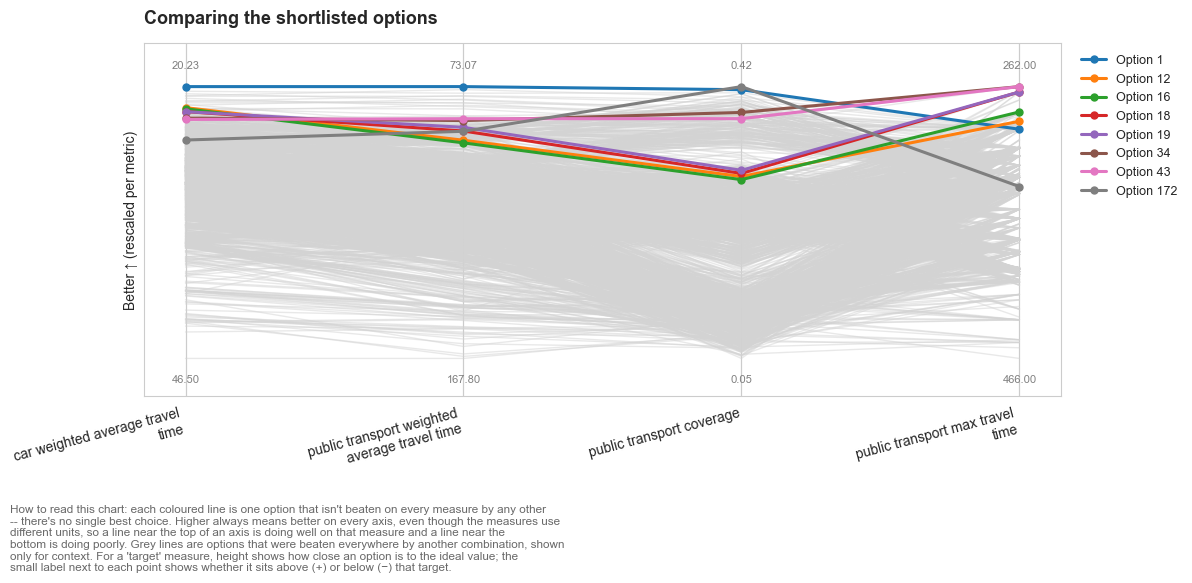

In [10]:
solution.plot_pareto_summary(width_multiplier=3);

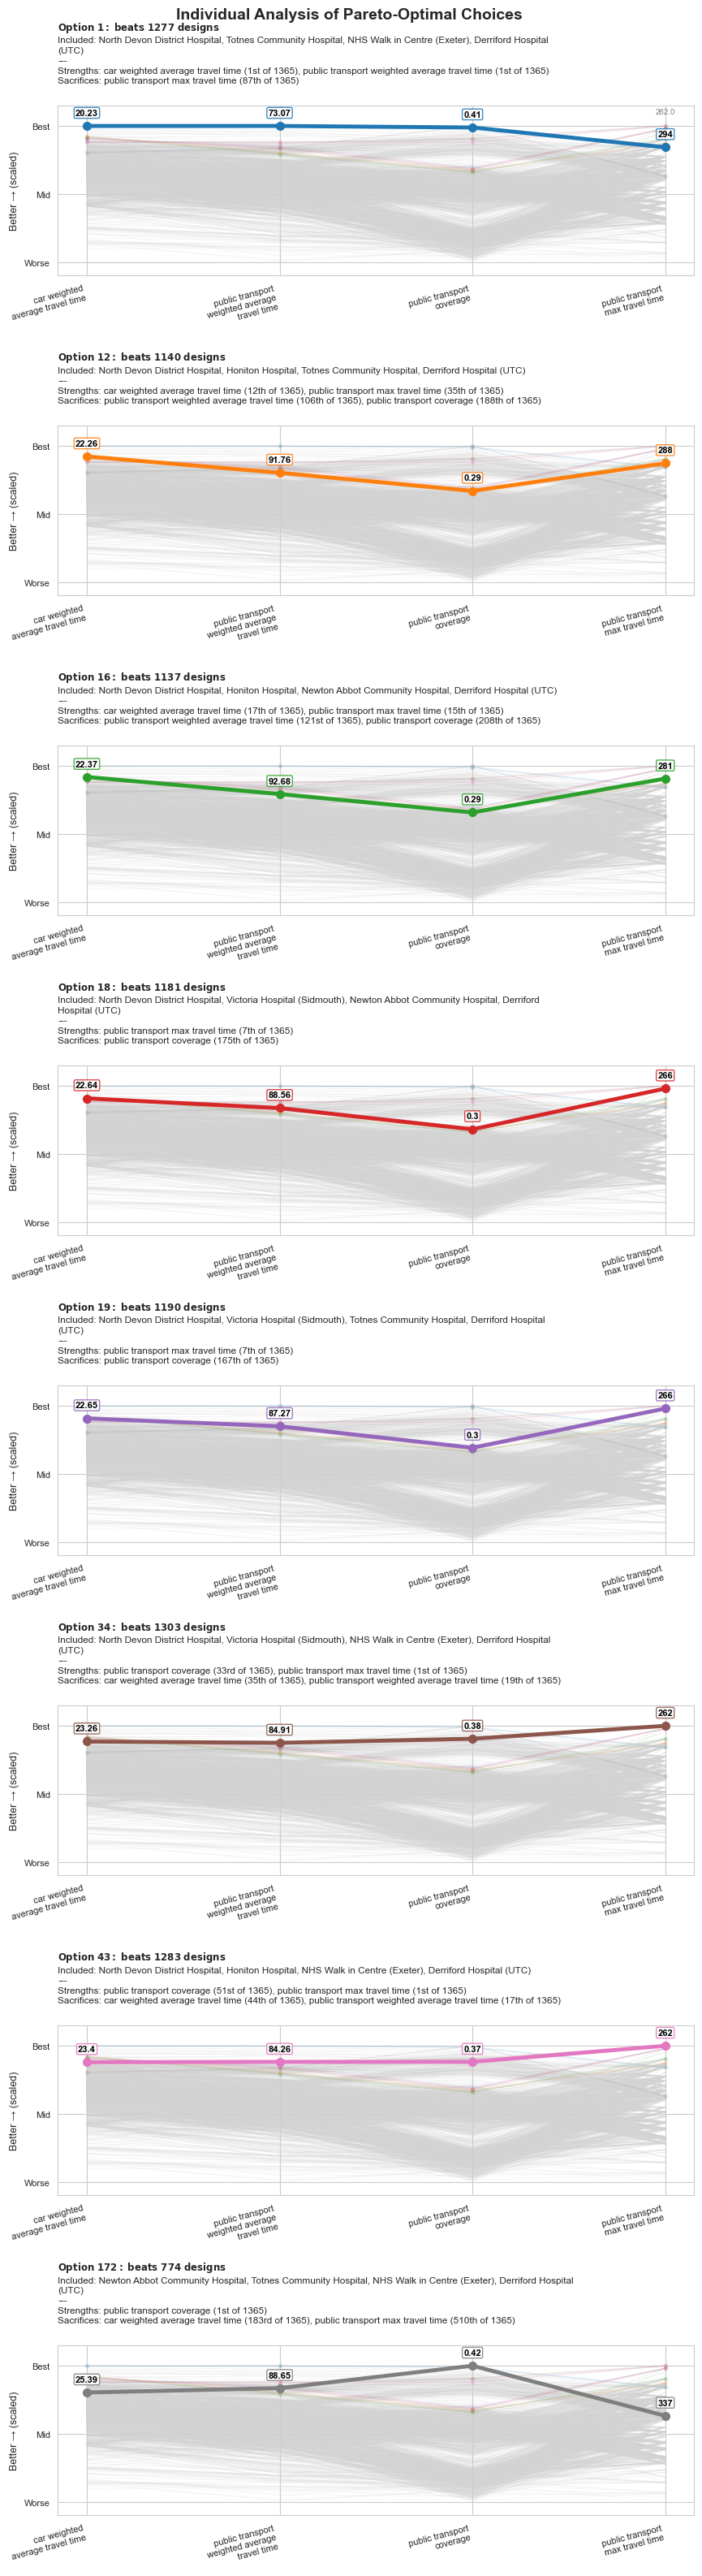

In [11]:
solution.plot_pareto_facets();

## Plotting a secondary matrix directly

Every travel-related plot accepts a `matrix=` keyword to switch from the primary (car) matrix to a registered secondary one. For example, here's the public transport travel time distribution for the best car-ranked solution, instead of its car travel times:

In [12]:
solution.plot_travel_time_distribution(matrix="public_transport", top_n=1)

The same `matrix=` keyword works on `plot_best_combination()`, `plot_n_best_combinations()`, `plot_solution_comparison()`, `check_solution_equity()`, `plot_top_n_solution_equity()`, and `plot_combination_by_equity()`.

## Maps

This ability to specify the matrix also applies to map plots. 

If we do not pass a matrix argument, it will default to the primary travel matrix. 

**Car**

C:\lokigi\lokigi\mixins\site_solution_plots.py:1501: UserWarning:

Unable to download background map tiles (ReadTimeout). Continuing without a basemap.



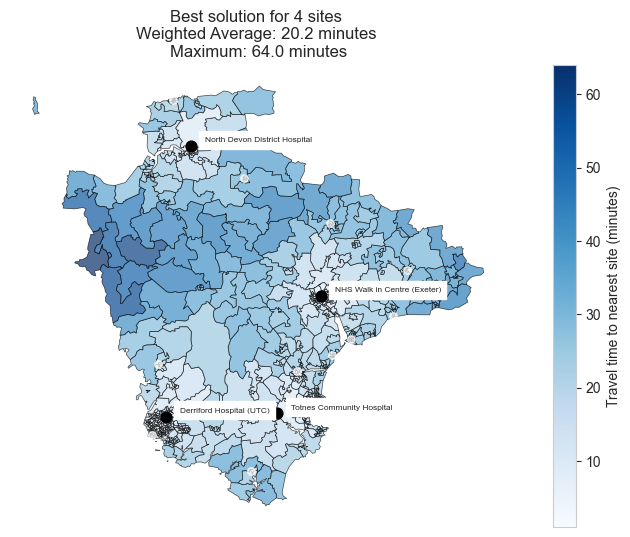

In [13]:
solution.plot_best_combination();

**Public Transport**

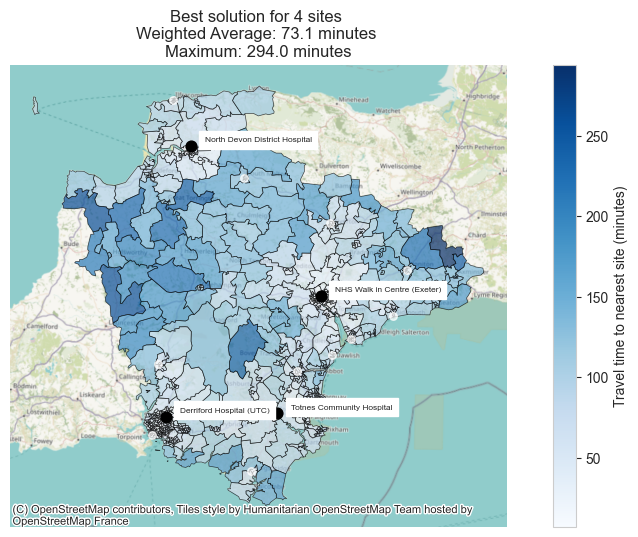

In [14]:
solution.plot_best_combination(matrix="public_transport");

## Ranking on a secondary matrix

Because `weighted_average__public_transport` is just another `solution_df` column, it can be used anywhere a column name is accepted -- including `rank_on`, to re-sort the *existing* set of solutions by public transport performance instead of car performance.

In [15]:
solution.return_best_combination_site_names(rank_on="weighted_average__public_transport")

['North Devon District Hospital',
 'Totnes Community Hospital',
 'NHS Walk in Centre (Exeter)',
 'Derriford Hospital (UTC)']

**A caveat worth knowing about:** `rank_on` only re-sorts the candidates that `solve()` already searched and kept. If you ran `solve(..., brute_force_keep_best_n=...)`, discarded combinations were pruned using *car* performance alone -- so a `public_transport`-ranked result over what survives is not necessarily the true best combination for public transport. When you're planning to explore secondary-matrix trade-offs, it's safest to solve with every combination retained (the default, or `brute_force_keep_best_n=None`), exactly as we've done in this example.

## Handling genuinely unreachable journeys

Look again at the public transport matrix registered above -- some of its values are `9999`:

In [16]:
problem.show_secondary_travel_matrix("public_transport").drop(columns="from_id").max().sort_values(ascending=False).head()

Honiton Hospital                          9999.0
South Hams Hospital (Kingsbridge)         9999.0
Ilfracombe & District Tyrrell Hospital     543.0
Totnes Community Hospital                  536.0
North Devon District Hospital              515.0
dtype: float64

`9999` here is a sentinel: whoever generated this matrix used it to mean "no public transport route found" for a handful of origin-destination pairs, rather than leaving those cells empty -- a common workaround, since `add_secondary_travel_matrix()` used to reject missing values outright. The problem is that `9999` isn't actually excluded from anything downstream -- it's just a very large, very wrong number that every average, maximum, and map colour scale treats as a real 12+ hour journey.

Watch what it does to a single-site solution built around South Hams Hospital, the site with the most `9999`s:

In [17]:
corrupted = problem.evaluate_baseline(
    site_names=["South Hams Hospital (Kingsbridge)"], threshold_for_coverage=20
    )
corrupted.solution_df[["weighted_average__public_transport", "max__public_transport"]]

,weighted_average__public_transport,max__public_transport
0,732.165488,9999.0


A demand-weighted average public transport journey of over 12 hours, and a reported maximum of exactly `9999` -- neither is a real travel time; both are the sentinel leaking into metrics that are supposed to describe actual journeys.

### The fix: `allow_missing` and `treat_as_missing`

`add_secondary_travel_matrix()` (and `add_travel_matrix()` for a primary matrix) accepts `allow_missing=True` to register a matrix that genuinely has no feasible journey for some pairs, and `treat_as_missing=<value>` to convert an existing sentinel like `9999` to a proper missing value first. Missing values are then treated as "no feasible journey" throughout -- excluded from every average/maximum, and rendered as a distinct grey region on maps, rather than either crashing or silently corrupting the numbers.

Since a label can only be registered once per problem, we register a fresh `SiteProblem` with the corrected registration (the sites/region-layer/car-matrix setup is identical to the top of this notebook):

In [18]:
problem_honest = SiteProblem()

problem_honest.add_sites(
    "../../../sample_data/devon_mius.geojson",
    candidate_id_col="Facility_Name"
    )

problem_honest.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

problem_honest.add_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix.csv",
    source_col="from_id",
    unit="minutes",
    )

problem_honest.add_secondary_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix_public_transport_extended.csv",
    source_col="from_id",
    label="public_transport",
    unit="minutes",
    threshold_for_coverage=60,
    allow_missing=True,
    treat_as_missing=9999,
    )

Evaluating the same single-site solution now gives an honest average -- computed only over regions that can actually reach the site by public transport -- alongside an explicit count of how many, and how much demand, couldn't:

In [19]:
honest = problem_honest.evaluate_baseline(
    site_names=["South Hams Hospital (Kingsbridge)"], threshold_for_coverage=20
    )
honest.solution_df[[
    "weighted_average__public_transport",
    "max__public_transport",
    "regions_unreachable__public_transport",
    "demand_unreachable__public_transport",
    "proportion_demand_unreachable__public_transport",
    ]]

C:\lokigi\lokigi\site.py:647: UserWarning:

No demand data was provided. Demand from all regions has been assumed to be equal. If you wish to override this, run .add_demand() to add your demand dataframe before calling evaluate_baseline() again.



,weighted_average__public_transport,max__public_transport,regions_unreachable__public_transport,demand_unreachable__public_transport,proportion_demand_unreachable__public_transport
0,191.137725,399.0,39,39.0,0.055163


191 minutes and a maximum of 399 -- both real, honest journey times -- plus an explicit "39 of 707 regions (5.5% of assumed-equal demand) have no public transport route at all" that used to be invisible, baked silently into a nonsensical 732-minute average.

The map reflects the same honesty: unreachable regions are shaded a distinct grey rather than left an unexplained hole, and the title states the count directly.

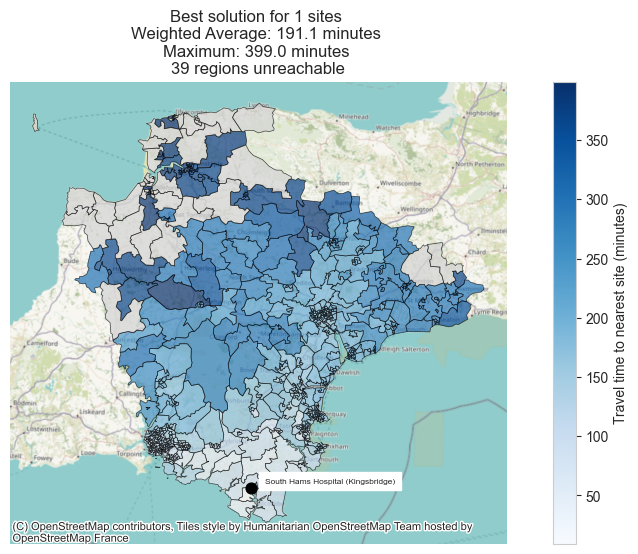

In [20]:
honest.plot_best_combination(matrix="public_transport", show_all_locations=False);

**When would you actually use this?** Public transport (or walking/cycling) matrices are usually generated with a permissive search radius/time limit to keep generation fast -- see [obtaining travel time matrices](../../travel_time_matrices/obtaining_travel_time_matrices_limits/index.ipynb) -- which means some pairs genuinely have no route within that limit. `allow_missing`/`treat_as_missing` let you register that matrix as-is instead of widening the search (slow) or inventing a sentinel (corrupting). If the *primary* matrix (the one `solve()` optimises against, car in this example) has missing values, `solve()` additionally requires `unreachable_cost=<a number>` -- a cost assumed for unreachable pairs *only* when ranking/pruning combinations, never in the reported metrics above -- since otherwise a combination could be silently rewarded for stranding demand behind an unreachable pair. Secondary matrices, as used here, never drive optimisation, so no such policy is needed.

## Which approach should I use?

- **Secondary travel matrices** (this example): one `solve()`, one ranked list, with every registered matrix's metrics available side by side. Best when you want to explore trade-offs *between* modes for the same candidate solutions -- e.g. with a Pareto front.
- **`problem.copy()` + `SolutionComparator`** (see [the comparing solutions example](../comparing_solutions/index.ipynb)): two independent solves, each optimised (and pruned) entirely on its own mode. Best when the two modes genuinely need separate optimisations -- e.g. very different candidate site sets, capacities, or objectives per mode -- and you want `find_balanced_solution()`'s rank-overlap heuristic to reconcile them afterwards.